# Lab 19: Scatter Plots - Data Visualization
## IBM Data Analytics Capstone Project 
### Objective: Create and analyze scatter plots to examine relationships between variables and identify trends

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

# Map Age to numeric
age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
df['Age_Numeric'] = df['Age'].map(age_mapping)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (65437, 115)


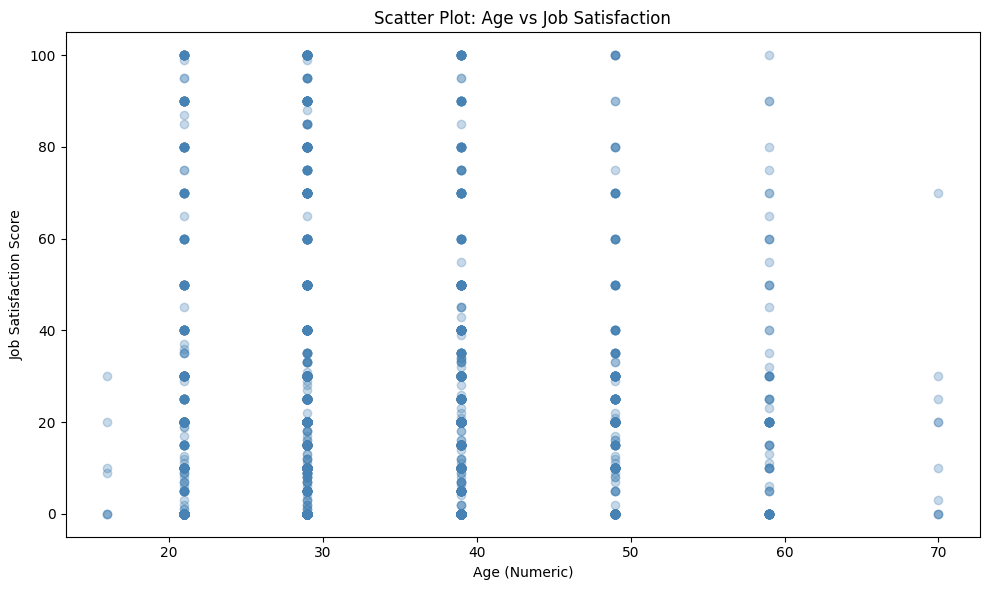

Age vs JobSat scatter saved!


In [2]:
# Sample for performance
sample = df[['Age_Numeric', 'JobSatPoints_6']].dropna().sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['Age_Numeric'], sample['JobSatPoints_6'],
            alpha=0.3, color='steelblue')
plt.title('Scatter Plot: Age vs Job Satisfaction')
plt.xlabel('Age (Numeric)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('scatter_age_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Age vs JobSat scatter saved!")

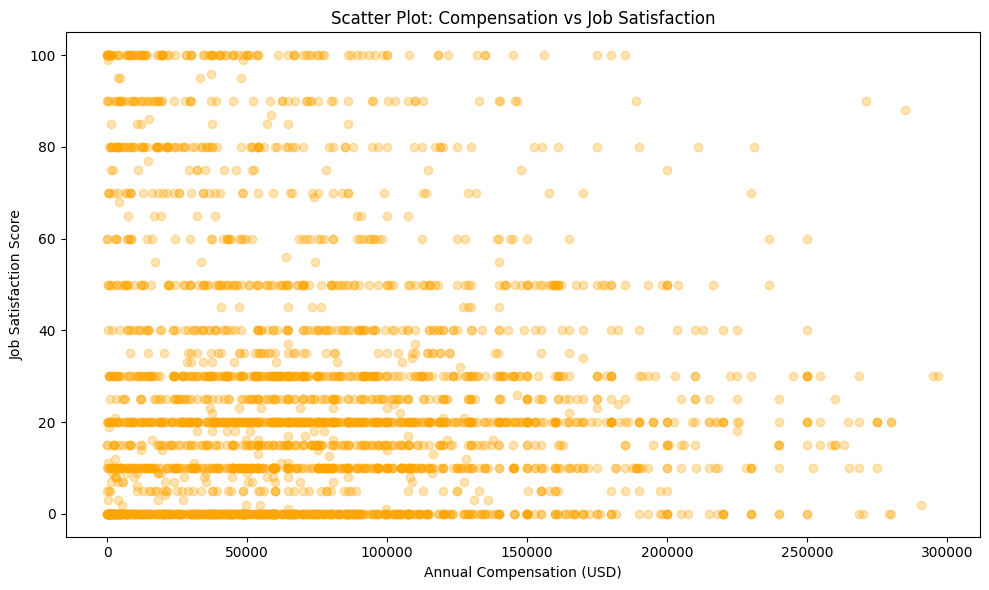

Compensation vs JobSat scatter saved!


In [3]:
sample = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['ConvertedCompYearly'], sample['JobSatPoints_6'],
            alpha=0.3, color='orange')
plt.title('Scatter Plot: Compensation vs Job Satisfaction')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('scatter_comp_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation vs JobSat scatter saved!")

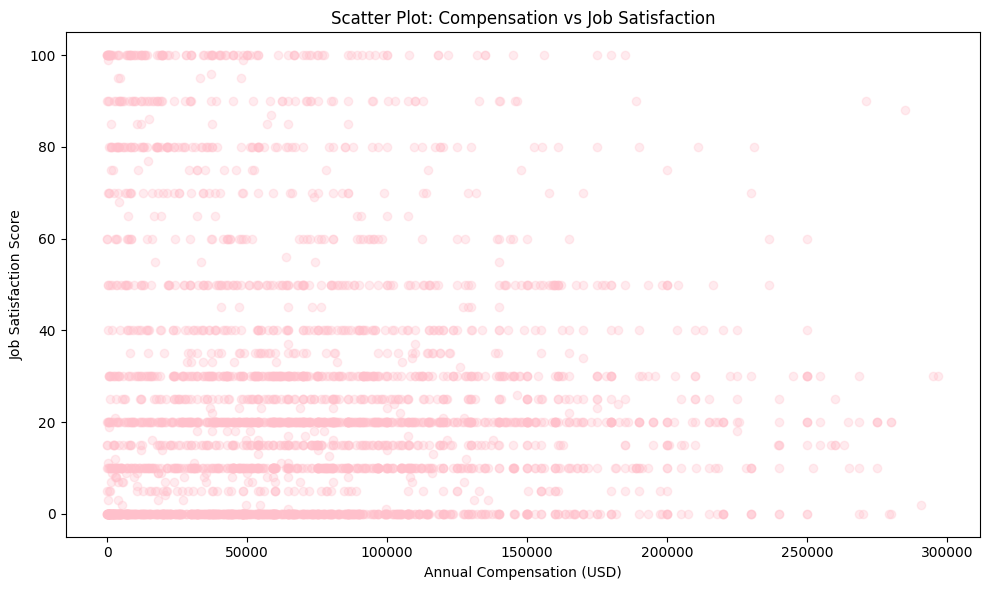

Compensation vs JobSat scatter saved!


In [5]:
sample = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['ConvertedCompYearly'], sample['JobSatPoints_6'],
            alpha=0.3, color='pink')
plt.title('Scatter Plot: Compensation vs Job Satisfaction')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('scatter_comp_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation vs JobSat scatter saved!")

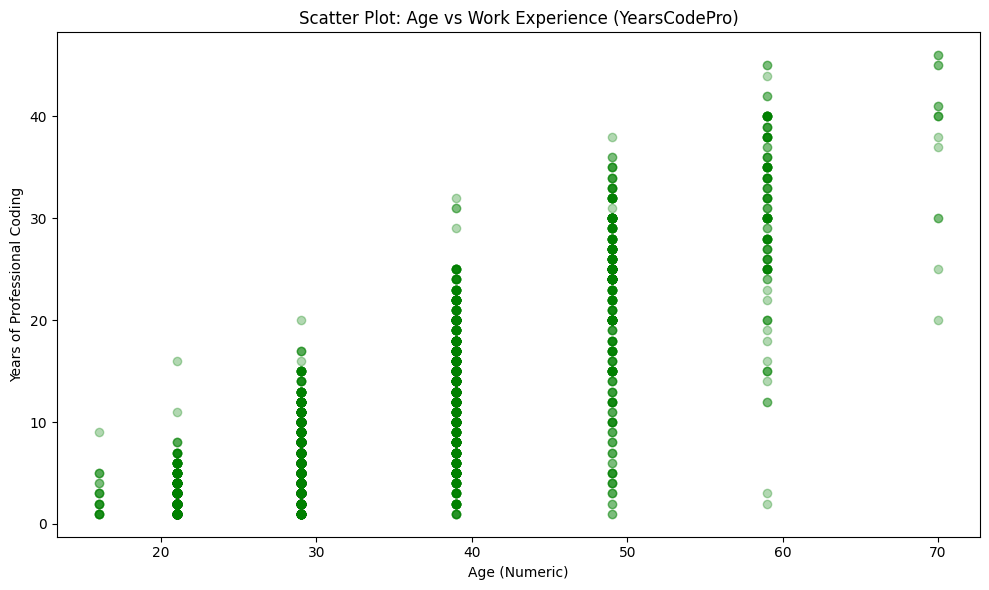

Age vs WorkExp scatter saved!


In [6]:
sample = df[['Age_Numeric', 'YearsCodePro']].dropna().sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['Age_Numeric'], sample['YearsCodePro'],
            alpha=0.3, color='green')
plt.title('Scatter Plot: Age vs Work Experience (YearsCodePro)')
plt.xlabel('Age (Numeric)')
plt.ylabel('Years of Professional Coding')
plt.tight_layout()
plt.savefig('scatter_age_workexp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Age vs WorkExp scatter saved!")

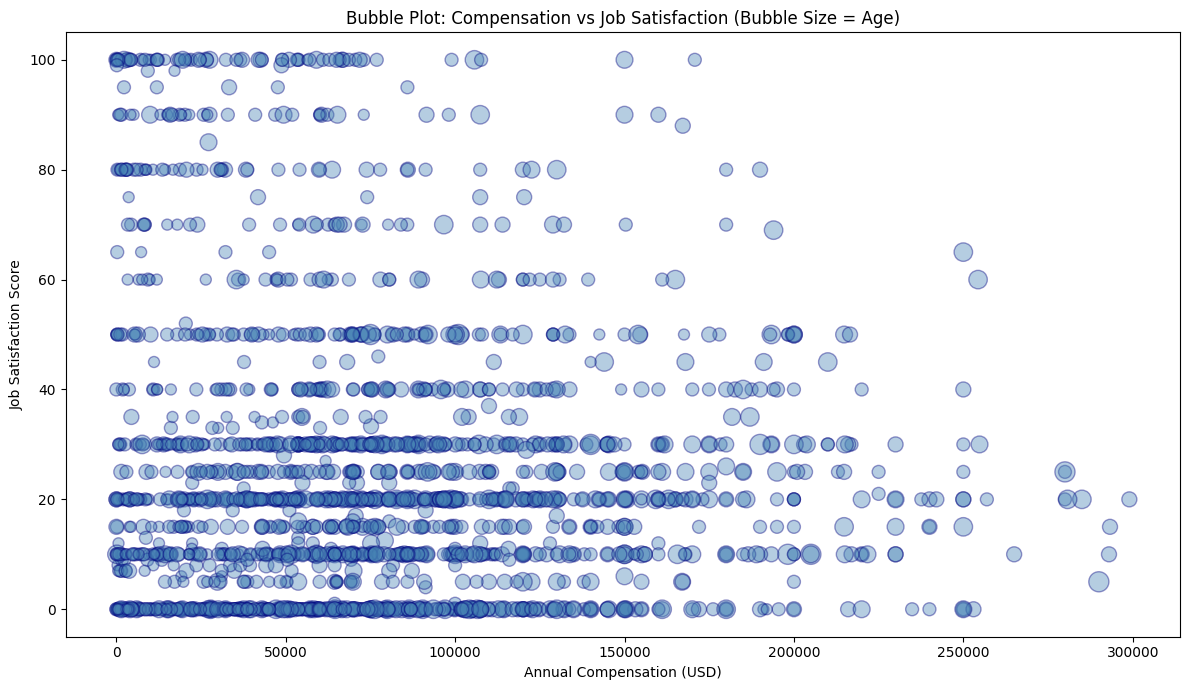

Bubble plot saved!


In [7]:
sample = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_Numeric']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(2000, random_state=42)

plt.figure(figsize=(12, 7))
plt.scatter(sample['ConvertedCompYearly'], sample['JobSatPoints_6'],
            s=sample['Age_Numeric'] * 3,
            alpha=0.4, color='steelblue', edgecolors='navy')
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('bubble_comp_jobsat_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bubble plot saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89437/3199542915.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['LanguageHaveWorkedWith'].str.contains(lang, na=False)


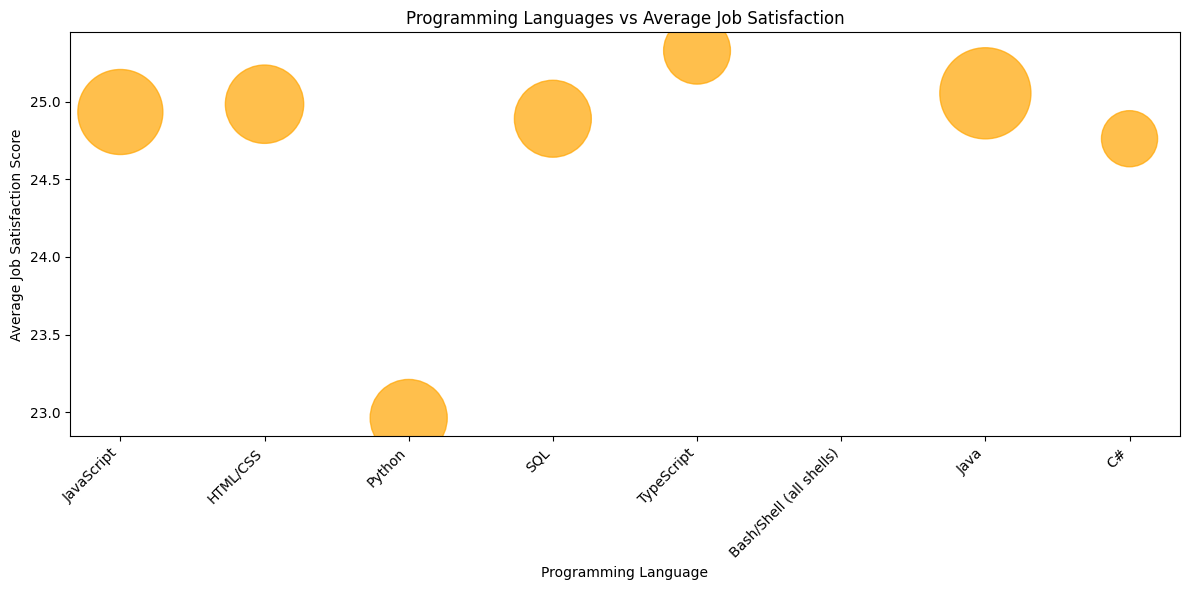

Languages vs JobSat scatter saved!
                  Language  AvgJobSat
0               JavaScript  24.932811
1                 HTML/CSS  24.983012
2                   Python  22.963746
3                      SQL  24.889480
4               TypeScript  25.327332
5  Bash/Shell (all shells)        NaN
6                     Java  25.053214
7                       C#  24.760905


In [8]:
# Top 8 languages and their avg job satisfaction
lang_series = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
top8_langs = lang_series.value_counts().head(8).index.tolist()

lang_jobsat = []
for lang in top8_langs:
    mask = df['LanguageHaveWorkedWith'].str.contains(lang, na=False)
    avg_sat = df[mask]['JobSatPoints_6'].mean()
    count = mask.sum()
    lang_jobsat.append({'Language': lang, 'AvgJobSat': avg_sat, 'Count': count})

df_lang = pd.DataFrame(lang_jobsat)

plt.figure(figsize=(12, 6))
plt.scatter(df_lang['Language'], df_lang['AvgJobSat'],
            s=df_lang['Count']/10, alpha=0.7, color='orange')
plt.title('Programming Languages vs Average Job Satisfaction')
plt.xlabel('Programming Language')
plt.ylabel('Average Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('scatter_lang_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Languages vs JobSat scatter saved!")
print(df_lang[['Language', 'AvgJobSat']].to_string())

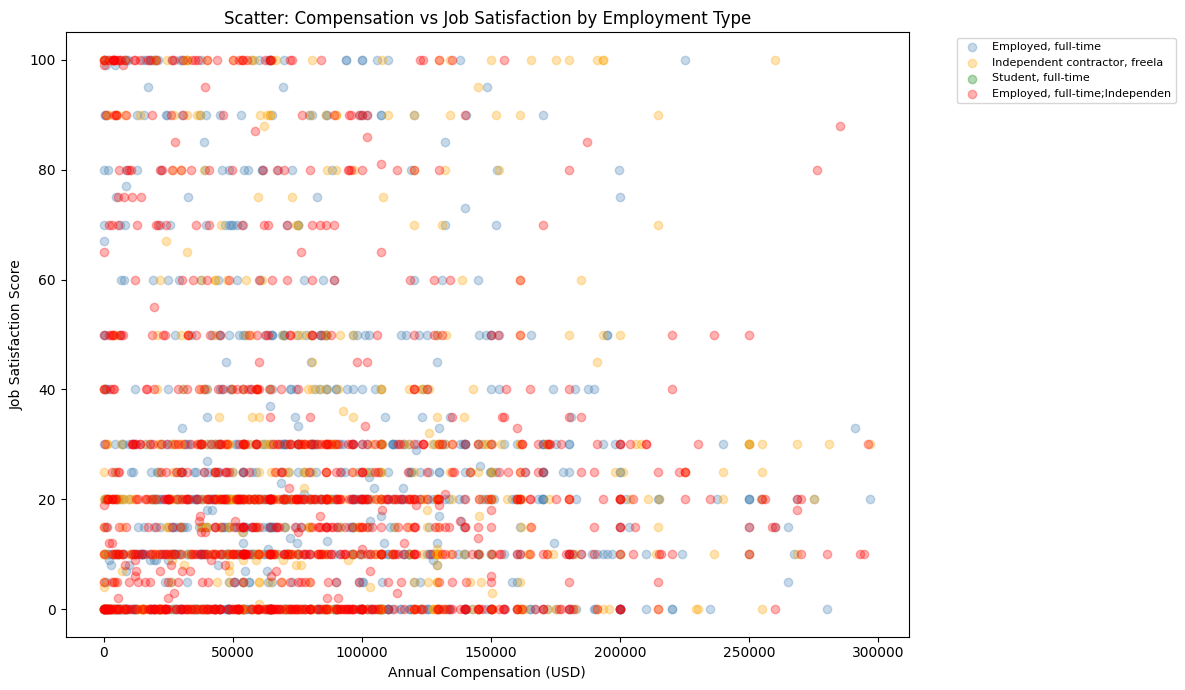

Comp vs JobSat by employment type saved!


In [9]:
# Top 4 employment types
top4_emp = df['Employment'].value_counts().head(4).index.tolist()
colors = ['steelblue', 'orange', 'green', 'red']

plt.figure(figsize=(12, 7))
for emp, color in zip(top4_emp, colors):
    mask = df['Employment'] == emp
    sample = df[mask][['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
    sample = sample[sample['ConvertedCompYearly'] < 300000]
    if len(sample) > 1000:
        sample = sample.sample(1000, random_state=42)
    plt.scatter(sample['ConvertedCompYearly'], sample['JobSatPoints_6'],
                alpha=0.3, color=color, label=emp[:30])

plt.title('Scatter: Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('scatter_comp_jobsat_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comp vs JobSat by employment type saved!")

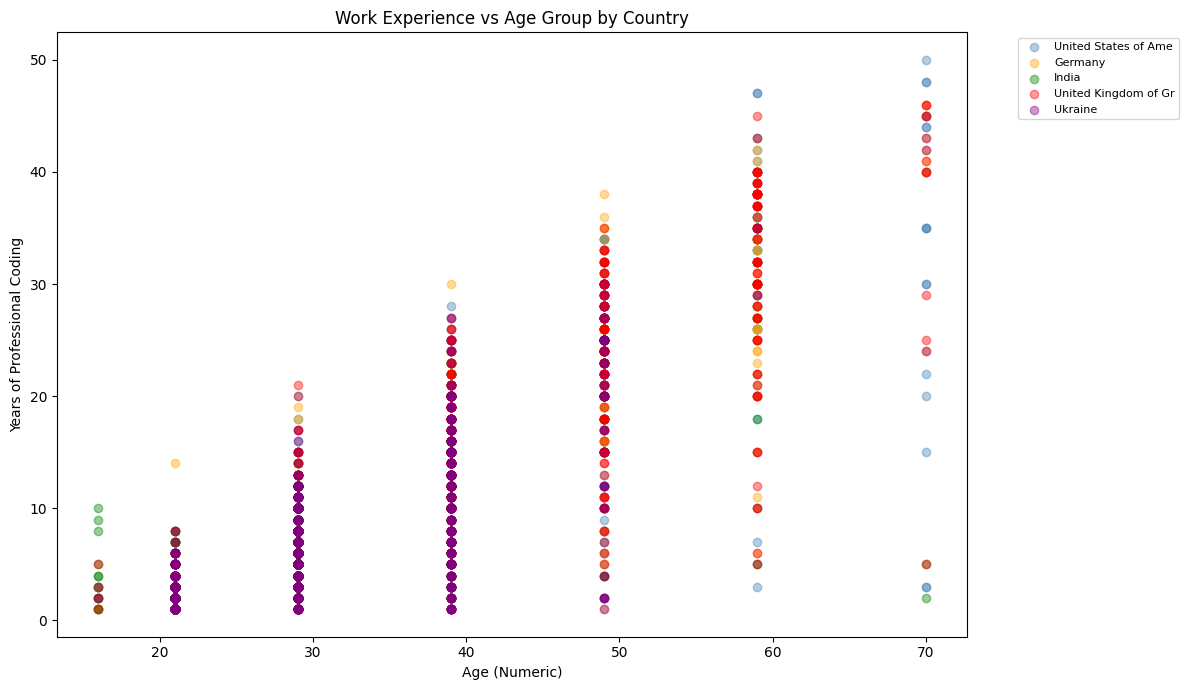

WorkExp vs Age by country saved!


In [10]:
# Top 5 countries
top5_countries = df['Country'].value_counts().head(5).index.tolist()
colors = ['steelblue', 'orange', 'green', 'red', 'purple']

plt.figure(figsize=(12, 7))
for country, color in zip(top5_countries, colors):
    mask = df['Country'] == country
    sample = df[mask][['Age_Numeric', 'YearsCodePro']].dropna()
    if len(sample) > 1000:
        sample = sample.sample(1000, random_state=42)
    plt.scatter(sample['Age_Numeric'], sample['YearsCodePro'],
                alpha=0.4, color=color, label=country[:20])

plt.title('Work Experience vs Age Group by Country')
plt.xlabel('Age (Numeric)')
plt.ylabel('Years of Professional Coding')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('scatter_workexp_age_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("WorkExp vs Age by country saved!")